In [1]:
from notebook_env import *
from mpltern.datasets import get_triangular_grid

RANDOM_SEED = 123
random_state = np.random.default_rng(RANDOM_SEED)

In [2]:
P = np.array(get_triangular_grid(26))
P_singletons = np.array(get_triangular_grid(2))
P

array([[1.  , 0.96, 0.96, ..., 0.  , 0.  , 0.  ],
       [0.  , 0.04, 0.  , ..., 0.08, 0.04, 0.  ],
       [0.  , 0.  , 0.04, ..., 0.92, 0.96, 1.  ]])

In [3]:
def calculate_population_game_sample(*, pop, clf_factory, P, n_train, n_test, n_reps, random_state):   
    results = []
    for p in tqdm(P.T, desc='Population game'):
        for rep in range(n_reps):
            clf = clf_factory()
            clf.fit(*pop.sample_from_mixture(
                n=n_train,
                p=p,
                random_state=random_state,
            )[:2])
            results.append({
                'rep': rep,
                'p': tuple(p),
                'clf': clf,
                'acc': [
                    clf.score(*pop.sample_from_group(n_test,i,random_state))
                    for i in range(3)
                ],
            })
            results[-1]['acc_p'] = np.array(results[-1]['p'])@results[-1]['acc']
    
    return pd.DataFrame(results)

<Axes: title={'center': 'Data distribution'}, xlabel='$x_1$', ylabel='$x_2$'>

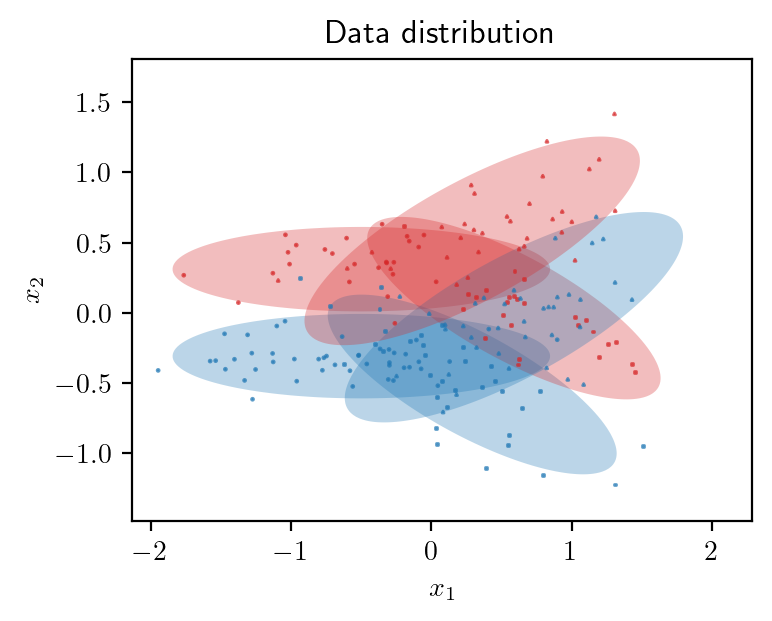

In [4]:
group_offset = np.array([0,0.5])
group_params = dict(
    sigma_y = 0.4,
    sigma_x = 0.02,
    d = 0.31,
)

pop = evoml.Population(groups=[
    evoml.GaussianPopulationGroup.bivariate_from_angle_offset(
        theta=np.pi/2,
        offset=group_offset,
        **group_params,
    ),
    evoml.GaussianPopulationGroup.bivariate_from_angle_offset(
        theta=np.pi/2-0.5,
        offset=-group_offset,
        **(group_params|{'sigma_x':0.03, 'sigma_y':0.3}),
        # **group_params,
    ),
    evoml.GaussianPopulationGroup.bivariate_from_angle_offset(
        theta=np.pi/2 + 0.5,
        offset=-group_offset,
        **(group_params|{'sigma_x':0.04}),
    ),
])


fig,ax=plt.subplots(figsize=(4,3))
evoml.plot_population_distribution(pop,ax=ax,random_state=random_state)


In [5]:
game_df = calculate_population_game_sample(
    pop=pop,
    clf_factory=lambda: evoml.TwoDimensionalEnumerationLinearClassifier(grid_n=200),
    P=P,
    n_train=1000,
    n_test=1000,
    n_reps=100,
    random_state=random_state,
)

Population game:   0%|          | 0/351 [00:00<?, ?it/s]

In [6]:
game_df.head()

,rep,p,clf,acc,acc_p
0,0,"(1.0, 0.0, 0.0)",<evoml.linear_classifier.TwoDimensionalEnumera...,"[0.9900000000000008, 0.7660000000000006, 0.718...",0.990
1,1,"(1.0, 0.0, 0.0)",<evoml.linear_classifier.TwoDimensionalEnumera...,"[0.9900000000000008, 0.7570000000000006, 0.728...",0.990
2,2,"(1.0, 0.0, 0.0)",<evoml.linear_classifier.TwoDimensionalEnumera...,"[0.9840000000000008, 0.7700000000000006, 0.742...",0.984
3,3,"(1.0, 0.0, 0.0)",<evoml.linear_classifier.TwoDimensionalEnumera...,"[0.9790000000000008, 0.7570000000000006, 0.760...",0.979
4,4,"(1.0, 0.0, 0.0)",<evoml.linear_classifier.TwoDimensionalEnumera...,"[0.9860000000000008, 0.7520000000000006, 0.731...",0.986


In [7]:
F_df = (
    game_df
    .set_index('p')['acc']
    .groupby(level=0)
    .agg(np.vstack)
    .map(lambda arr: arr.mean(axis=0))
    .reset_index()
    .assign(
        acc_p=lambda df: df.apply(lambda row: np.array(row['p'])@row['acc'], axis=1),
        rep_f=lambda df: df.apply(lambda row: np.array(row['p'])*(row['acc']-row['acc_p']), axis=1),
    )
    .set_index('p')
)
F_df

,acc,acc_p,rep_f
p,,,
"(0.0, 0.0, 1.0)","[0.7409900000000001, 0.5946700000000004, 0.938...",0.938150,"[-0.0, -0.0, 0.0]"
"(0.0, 0.040000000000000036, 0.96)","[0.7393800000000005, 0.5963900000000005, 0.938...",0.925267,"[-0.0, -0.01315507200000002, 0.013155072000000..."
"(0.0, 0.07999999999999996, 0.92)","[0.7464200000000001, 0.5966500000000005, 0.938...",0.910756,"[-0.0, -0.02512851200000005, 0.025128512000000..."
"(0.0, 0.12, 0.88)","[0.7467200000000005, 0.5990400000000003, 0.937...",0.897087,"[-0.0, -0.03576566400000006, 0.03576566400000008]"
"(0.0, 0.16000000000000003, 0.84)","[0.7511700000000003, 0.5986400000000001, 0.936...",0.882190,"[-0.0, -0.04536806400000013, 0.04536806400000008]"
...,...,...,...
"(0.92, 0.040000000000000036, 0.040000000000000036)","[0.9852500000000006, 0.7520700000000003, 0.729...",0.965694,"[0.017991519999999914, -0.008544960000000022, ..."
"(0.92, 0.07999999999999996, 0.0)","[0.9848200000000007, 0.7580400000000007, 0.727...",0.966678,"[0.016691008000000004, -0.01669100799999999, -..."
"(0.96, 0.0, 0.040000000000000036)","[0.984850000000001, 0.7477100000000001, 0.7325...",0.974759,"[0.009687551999999967, -0.0, -0.00968755200000..."


Figure saved as ./output/ternary.pdf


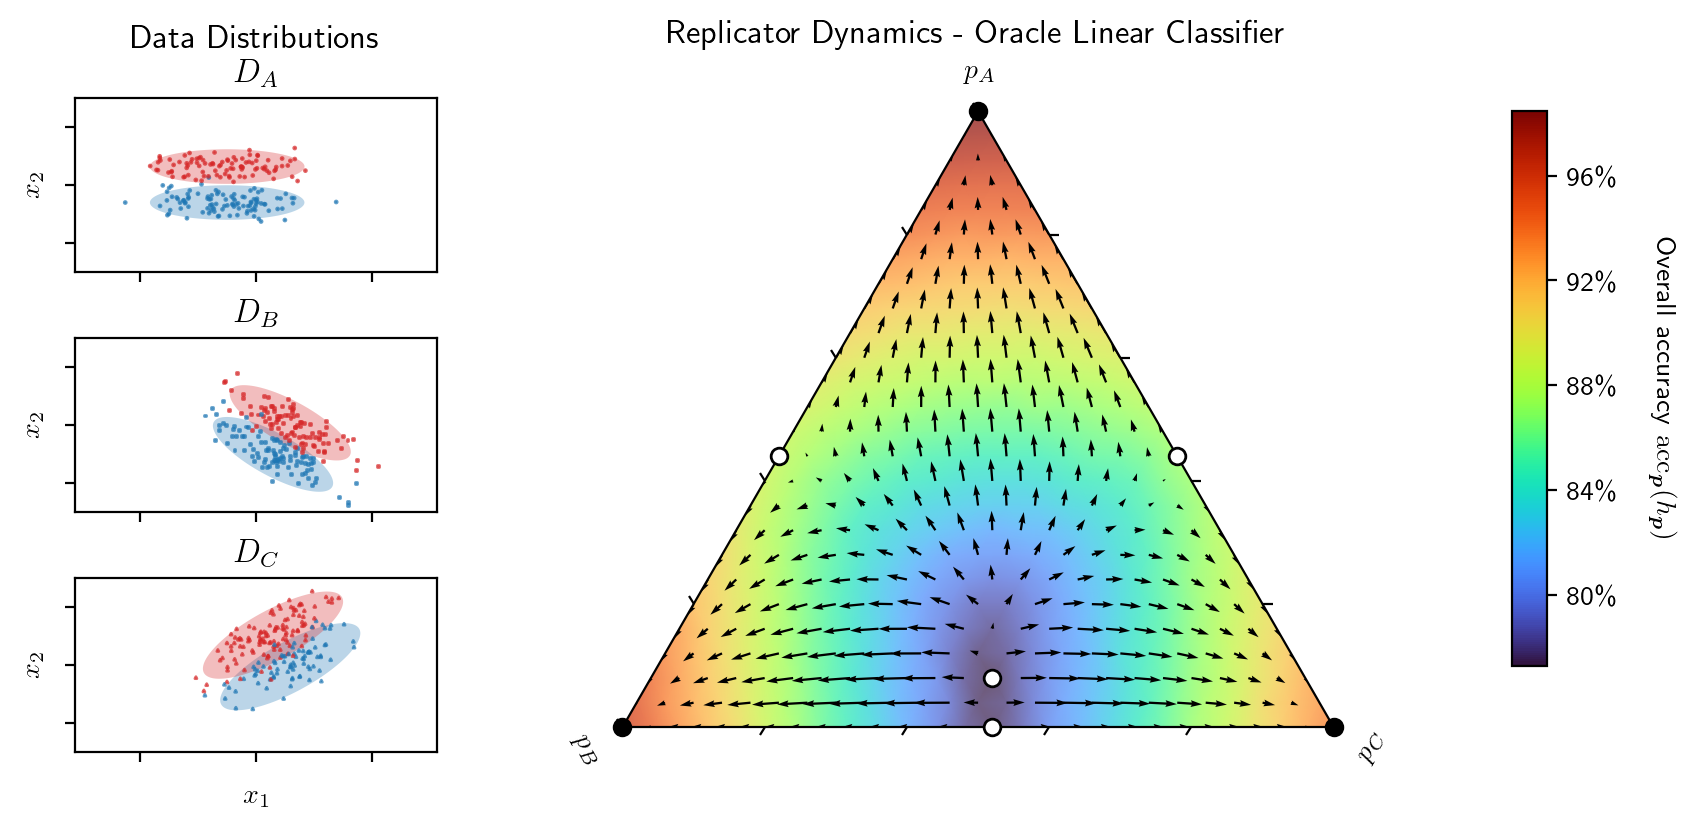

In [8]:
marker_params=dict(
    # markersize=4,
    clip_on=False,
    zorder=100,
    marker='o',
    edgecolors='black',
)

def plot_ternary(pop, F_df, *, quiver_kwargs={}, colorbar_kwargs={}, plot_equilibria=True):
    acc_P = np.array([F_df['acc_p'].to_dict()[tuple(p)] for p in P.T])
    replicator_f = np.array([F_df['rep_f'].to_dict()[tuple(p)] for p in P.T])
    fig,axs=plt.subplot_mosaic(
        '''
        AF
        BF
        CF
        ''',
        figsize=(7.6,4),
        per_subplot_kw={
            'F': {
                'projection': 'ternary',
            },
        },
        layout='constrained',
        width_ratios=[1,3],
    )

    for i in range(3):
        gid = 'ABC'[i]
        ax = axs[gid]
        evoml.plot_population_distribution(
            pop,
            ax=ax,
            mixture_kwargs=dict(
                p=np.arange(3)==i,
            ),
            random_state=random_state,
        )
        ax.set(
            title=f'$D_{gid}$',
            xlabel=None,
            xticklabels=[],
            ylabel='$x_2$',
            yticklabels=[],
            xlim=(-1,1),
        )
        if i==0:
            ax.set(
                title=f'Data Distributions\n$D_{gid}$',
            )
        if i==2:
            ax.set(
                xlabel='$x_1$',
            )
    
    ax = axs['F']
    potential_plot = ax.tripcolor(
        *P,
        acc_P*100,
        cmap='turbo',
        shading='gouraud',
    )
    ax.tripcolor(
        *P_singletons,
        P_singletons[0]*0,
        cmap='binary',
        shading='gouraud',
        alpha=0.3,
    )
    ax.quiver(
        *P,
        *replicator_f.T,
        **(dict(scale=1.8, clip_on=True) | quiver_kwargs),
    )
    
    cax = ax.inset_axes([1.25, 0.1, 0.05, 0.9], transform=ax.transAxes)
    colorbar = fig.colorbar(
        potential_plot,
        cax=cax,
        **(dict(format='{x:.0f}\\%', ticks=matplotlib.ticker.MultipleLocator(4))|colorbar_kwargs),
    )
    colorbar.set_label(r'Overall accuracy $\mathrm{acc}_{\vp}(h_{\vp})$'+'\n', rotation=270, va="baseline")
    
    ax.set(
        title='Replicator Dynamics - Oracle Linear Classifier',
        tlabel='$p_A$',
        llabel='$p_B$',
        rlabel='$p_C$',
    )
    for axis in 'tlr':
        getattr(ax,f'get_{axis}axis')().set_ticks(
            ticks=np.linspace(0,1,6),
            labels=['']*6,
        )
    
    pos = ax.get_position()
    ax.set_position([pos.x0, pos.y0, pos.width, pos.height])

    if plot_equilibria:
        ax.scatter(
            *P.T[acc_P.argmin()],
            color='white',
            **marker_params,
        )
        for p in P_singletons.T:
            ax.scatter(
                *p,
                color='black',
                **marker_params,
            )
        for i in range(3):
            ax.scatter(
                *P.T[(acc_P+(P[i]>0)).argmin()],
                color='white',
                # linestyle=':',
                **marker_params,
            )
    return fig,axs

fig,axs=plot_ternary(pop,F_df)
for g in 'ABC':
    axs[g].set(
        xlim=(-1,1),
        ylim=(-1.5,1.5),
    )
evoml.analysis.save_and_download_fig(fig, './output/ternary.pdf', bbox_inches='tight')


<Axes: title={'center': 'Data distribution'}, xlabel='$x_1$', ylabel='$x_2$'>

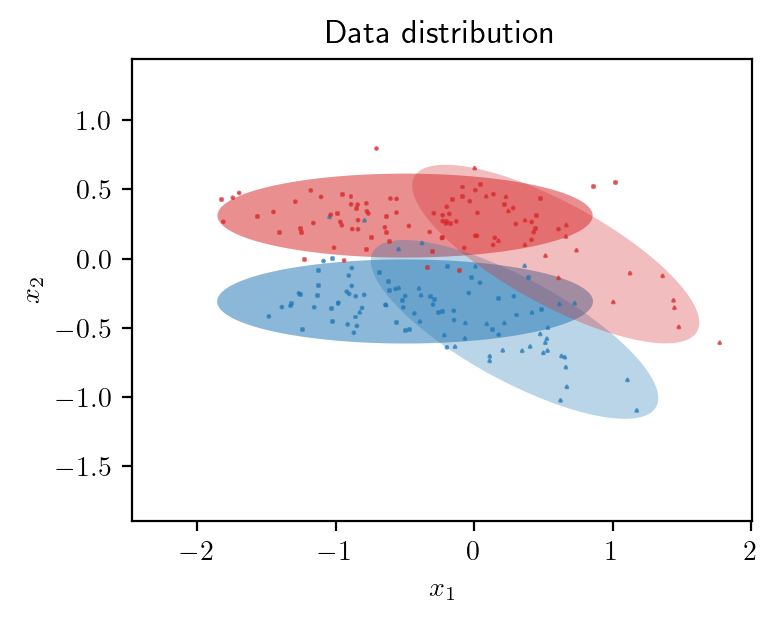

In [9]:
pop2 = evoml.Population(groups=[
    evoml.GaussianPopulationGroup.bivariate_from_angle_offset(
        theta=np.pi/2,
        offset=group_offset,
        **group_params,
    ),
    evoml.GaussianPopulationGroup.bivariate_from_angle_offset(
        theta=np.pi/2,
        offset=group_offset,
        **group_params,
    ),
    evoml.GaussianPopulationGroup.bivariate_from_angle_offset(
        theta=np.pi/2-0.5,
        offset=-group_offset,
        **(group_params|{'sigma_x':0.03, 'sigma_y':0.3}),
    ),
])


fig,ax=plt.subplots(figsize=(4,3))
evoml.plot_population_distribution(pop2,ax=ax,random_state=random_state)


In [10]:
game_df2 = calculate_population_game_sample(
    pop=pop2,
    clf_factory=lambda: evoml.TwoDimensionalEnumerationLinearClassifier(grid_n=200),
    P=P,
    n_train=1000,
    n_test=1000,
    n_reps=100,
    random_state=random_state,
)

Population game:   0%|          | 0/351 [00:00<?, ?it/s]

In [11]:
F_df2 = (
    game_df2
    .set_index('p')['acc']
    .groupby(level=0)
    .agg(np.vstack)
    .map(lambda arr: arr.mean(axis=0))
    .reset_index()
    .assign(
        acc_p=lambda df: df.apply(lambda row: np.array(row['p'])@row['acc'], axis=1),
        rep_f=lambda df: df.apply(lambda row: np.array(row['p'])*(row['acc']-row['acc_p']), axis=1),
    )
    .set_index('p')
)
F_df

,acc,acc_p,rep_f
p,,,
"(0.0, 0.0, 1.0)","[0.7409900000000001, 0.5946700000000004, 0.938...",0.938150,"[-0.0, -0.0, 0.0]"
"(0.0, 0.040000000000000036, 0.96)","[0.7393800000000005, 0.5963900000000005, 0.938...",0.925267,"[-0.0, -0.01315507200000002, 0.013155072000000..."
"(0.0, 0.07999999999999996, 0.92)","[0.7464200000000001, 0.5966500000000005, 0.938...",0.910756,"[-0.0, -0.02512851200000005, 0.025128512000000..."
"(0.0, 0.12, 0.88)","[0.7467200000000005, 0.5990400000000003, 0.937...",0.897087,"[-0.0, -0.03576566400000006, 0.03576566400000008]"
"(0.0, 0.16000000000000003, 0.84)","[0.7511700000000003, 0.5986400000000001, 0.936...",0.882190,"[-0.0, -0.04536806400000013, 0.04536806400000008]"
...,...,...,...
"(0.92, 0.040000000000000036, 0.040000000000000036)","[0.9852500000000006, 0.7520700000000003, 0.729...",0.965694,"[0.017991519999999914, -0.008544960000000022, ..."
"(0.92, 0.07999999999999996, 0.0)","[0.9848200000000007, 0.7580400000000007, 0.727...",0.966678,"[0.016691008000000004, -0.01669100799999999, -..."
"(0.96, 0.0, 0.040000000000000036)","[0.984850000000001, 0.7477100000000001, 0.7325...",0.974759,"[0.009687551999999967, -0.0, -0.00968755200000..."


Figure saved as ./output/ternary_equivalent_groups.pdf


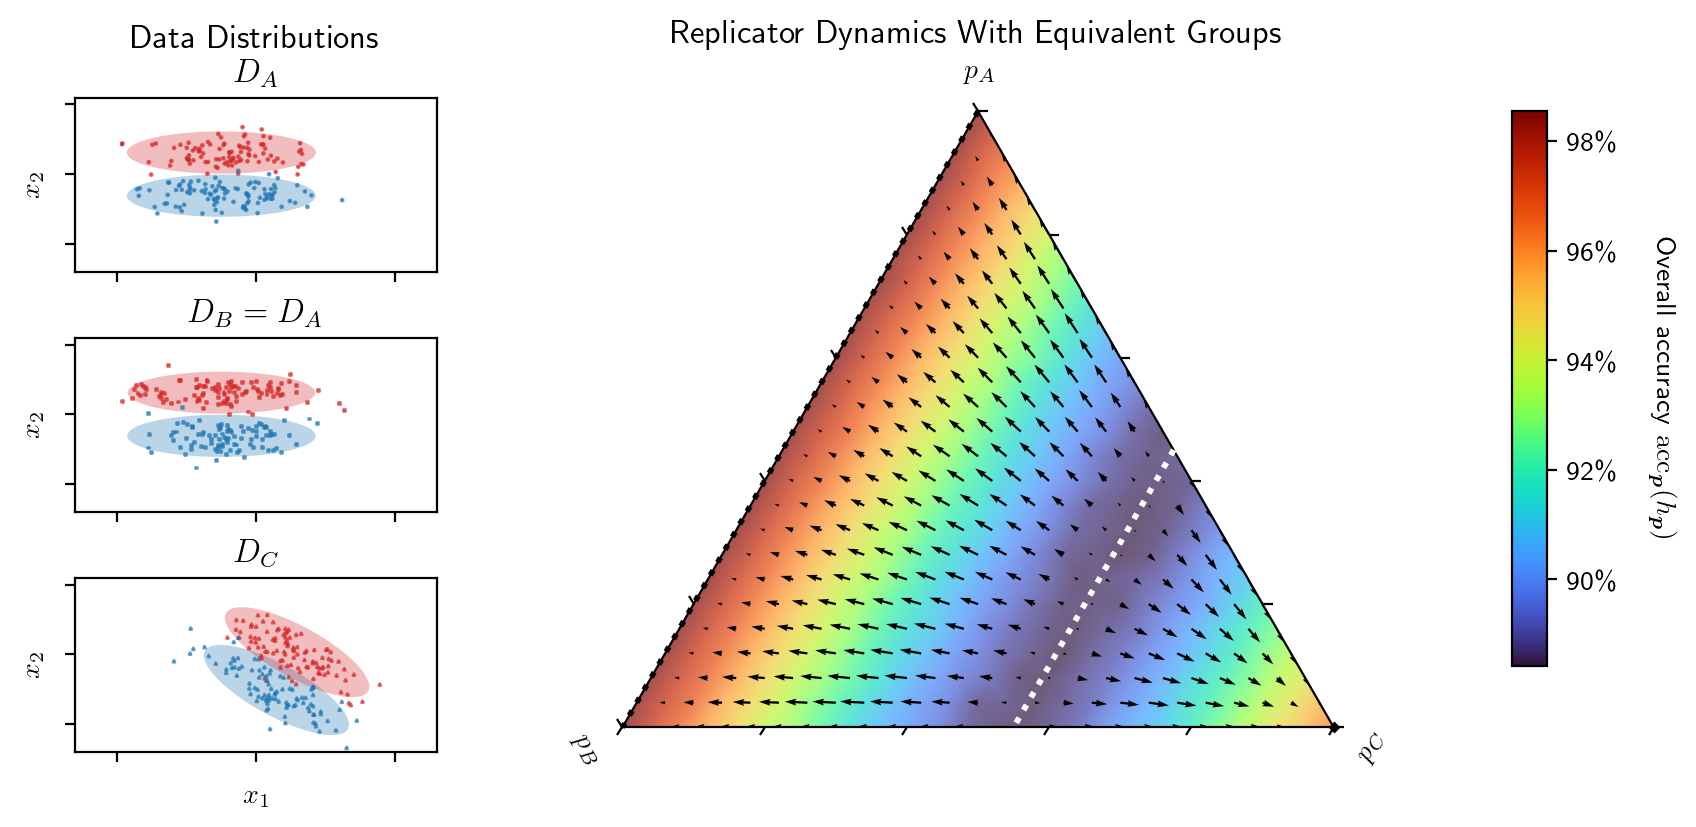

In [12]:
fig,axs=plot_ternary(
    pop2,F_df2,
    quiver_kwargs=dict(
        scale=1.3,
    ),
    colorbar_kwargs=dict(
        ticks=matplotlib.ticker.MultipleLocator(2),
    ),
    plot_equilibria=False,
)
for g in 'ABC':
    axs[g].set(
        xlim=(-1,1),
        ylim=(-1.4,1.1),
    )
ax = axs['F']
p0 = 0.45
p_vec = np.array([
    [p0*(1-t),p0*t,1-p0]
    for t in np.linspace(0,1,10)
])
ax.plot(
    [p0,0],[0,p0],[1-p0,1-p0],
    *p_vec.T,
    color='white',
    zorder=100,
    linestyle=':',
    linewidth=2,
    clip_on=False,
)
ax.plot(
    [1,0],[0,1],[0,0],
    color='black',
    linewidth=2,
    linestyle=':',
    clip_on=False,
)
ax.plot(
    0,0,1,
    color='black',
    marker='D',
    clip_on=False,
    markersize=2,
)

axs['B'].set(title='$D_B=D_A$')
axs['F'].set(title='Replicator Dynamics With Equivalent Groups')

evoml.analysis.save_and_download_fig(fig, './output/ternary_equivalent_groups.pdf', bbox_inches='tight')
